<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/english_part1_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Descent for Linear Regression. Part 1/2**
#### **Understanding the Algorithm and Basic Implementation**  


 <a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

 > **This is Part 1 of 2 in our series on Gradient Descent.**
> Here you'll learn the intuition, essential mathematics, and basic implementation of the algorithm. In Part 2, we'll cover hyperparameters, feature scaling, and professional implementations.

If you want to review the fundamentals of linear regression and the least squares method, I recommend reading my article [Linear Regression from Scratch in Python](https://www.kaggle.com/code/magnitopic/linear-regression-from-scratch-in-python-part-1-2) first, where these concepts are covered from scratch.

### The Star Algorithm of Machine Learning

Gradient Descent is the optimization engine behind virtually all modern Machine Learning. In this article, you'll learn how this algorithm works by applying it to Linear Regression, combining accessible theory with practical code so you understand **why it works** and **how to implement it** step by step.

By the end of this article, you'll have built your own Gradient Descent algorithm from scratch and will understand the foundation upon which neural networks are built.

## **1. Introduction: What Problem Are We Trying to Solve?**

At the heart of Machine Learning lies a fundamental task: **prediction**. We want to use data we already have to make intelligent estimates about data we haven't seen yet.

Let's take a classic and practical example: **predicting the price of a house based on its size**.

### The Prediction Problem

Imagine you have a dataset of houses. For each one, you know its **size in square meters** (our input variable $x$) and the **sale price** (our target variable $y$). If we plot this data on a scatter plot, we'll see a cloud of points with a clear trend: the larger the area, the higher the price (although with some dispersion).

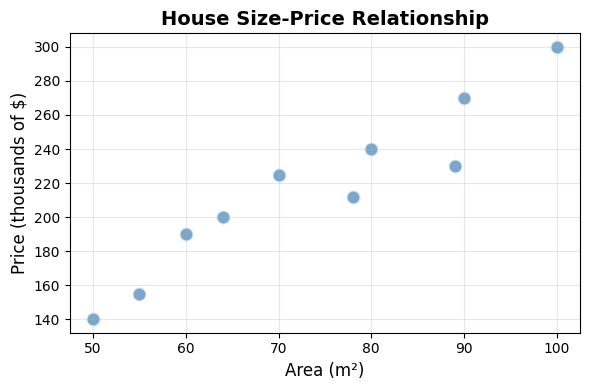

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data: house size vs price
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
price = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

plt.figure(figsize=(6, 4))
plt.scatter(area, price/1000, alpha=0.7, s=100, color='steelblue', edgecolors='white', linewidth=1.5)
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands of $)', fontsize=12)
plt.title('House Size-Price Relationship', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our goal is to find **a straight line** that best captures this trend. This line will be our **Linear Regression** model.

Why is this interesting? Because once the model is trained, if we're given the area of a new house ($x$), we can use the line to **estimate** its likely price ($\hat{y}$).

### The Model Equation

The equation of a straight line is well known:

$$\hat{y} = w_0 + w_1 x$$

Where:
- $x$: house area is our input variable (the *feature*).
- $\hat{y}$: estimated price is our model's prediction. We distinguish it from the actual $y$ (the true sale price).
- $w_0$: **intercept** or bias. Value of $\hat{y}$ when $x = 0$.
- $w_1$: **slope** or weight. How much the price increases for each additional square meter.

**Objective:** Find the parameters $ w_0 $ and $ w_1 $ that give us the line that best fits the cloud of points.

There are two main approaches:

1. **Closed-form Solution (Normal Equation)**  
   A direct analytical formula:  
   $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$  
   It's exact and fast for small datasets, but becomes very expensive (and sometimes impossible) with millions of data points or thousands of variables.

2. **Gradient Descent**  
   An iterative algorithm that "walks" toward optimal values by progressively adjusting the parameters.  
   **Key advantages:**
   - Scales to enormous datasets and thousands of features
   - Works with data that doesn't fit in memory (batch processing)
   - Is the foundation of virtually all Deep Learning
   - Allows continuous model updating (online learning)
   - Works for non-linear problems and neural networks

In real-world problems (hundreds of thousands or millions of observations), the closed-form solution simply isn't viable. That's why we need to understand and master **Gradient Descent**.

### What Will You Learn in This Part 1?

- The intuition behind the algorithm.
- How to measure a line's error: the **cost function**.
- The essential mathematics: what the gradient is and why "descending" leads us to the minimum.
- Implement Gradient Descent from scratch with NumPy.
- Visualize the optimization process and understand what happens internally at each step.

In **Part 2** we'll dive deeper into:
- critical hyperparameters (learning rate)
- feature scaling
- algorithm variants (Batch, Mini-Batch, SGD)
- comparison with professional implementations like scikit-learn.

But before implementing anything, we need to answer a fundamental question: how do we measure how "good" or "bad" a line is? For that, we'll introduce the Cost Function.

# **2. Measuring Error: The Cost Function**

To find the "best" line, we need an objective way to measure how well a line fits the data.

## **The Residual: Error at a Point**

For each house $i$, we know its actual area $x_i$ and its actual price $y_i$. Our line predicts a price $\hat{y}_i = w_0 + w_1 x_i$.

The vertical difference between the actual point and the prediction is called the **residual**:

$$e_i = y_i - \hat{y}_i$$

- If $e_i > 0$, the point is above the line (we underestimated the price).
- If $e_i < 0$, the point is below (we overestimated).

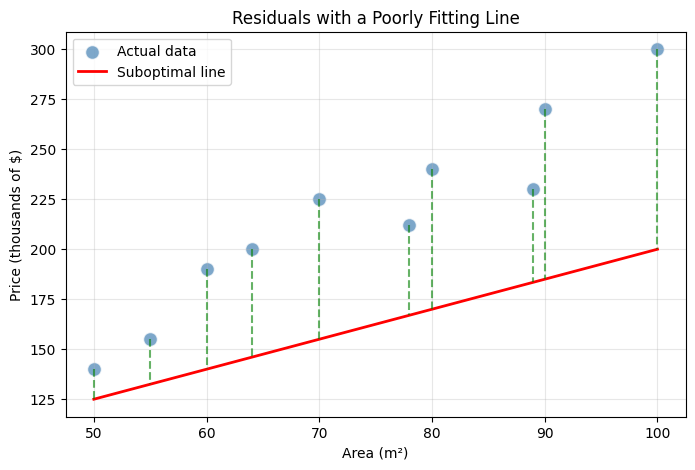

In [6]:
# Quick visualization of residuals with an arbitrary line
w0_bad, w1_bad = 50000, 1500
y_pred_bad = w0_bad + w1_bad * area

plt.figure(figsize=(8, 5))
plt.scatter(area, price/1000, s=100, alpha=0.7, color='steelblue', edgecolors='white', label='Actual data')
plt.plot(area, y_pred_bad/1000, 'r-', linewidth=2, label='Suboptimal line')
for i in range(len(area)):
    plt.plot([area[i], area[i]], [price[i]/1000, y_pred_bad[i]/1000], 'g--', alpha=0.6)
plt.xlabel('Area (m²)')
plt.ylabel('Price (thousands of $)')
plt.title('Residuals with a Poorly Fitting Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Total Error: Why Isn't Summing the Residuals Enough?

An initial impulse would be to sum all the residuals. But this is problematic: positive and negative errors cancel each other out, potentially giving the false impression that there's no error when in reality the line is very far from many points.

## Solution: Mean Squared Error (MSE)

To avoid cancellations and penalize large errors more:

1. We square each residual: $e_i^2 = (y_i - \hat{y}_i)^2$
    - always positive
    - penalizes large errors much more
2. We calculate the average of all squared errors, which gives us the Mean Squared Error (MSE).

### MSE Definition

The function $\text{MSE}(w)$ calculates the mean of the squared errors.

$$\text{MSE}(w) = \frac{1}{m} \sum_{i=1}^{m}e_i^2 = \frac{1}{m} \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = \frac{1}{m} \sum_{i=1}^{m}(y_i - (w_0 + w_1 x_i))^2$$

where $m$ is the number of data points.

In [7]:
def mse(w0, w1, x, y):
    """Calculates the Mean Squared Error"""
    m = len(y)
    y_pred = w0 + w1 * x
    return (1/m) * np.sum((y - y_pred)**2)

# Calculate the MSE for our suboptimal line
mse_bad = mse(w0_bad, w1_bad, area, price)
rmse_bad = np.sqrt(mse_bad)

print(f"MSE with the suboptimal line: {mse_bad:,.0f}")
print(f"RMSE (root of MSE): ${rmse_bad:,.0f}")
print(f"On average, predictions deviate about ${rmse_bad:,.0f} from the actual price")

MSE with the suboptimal line: 3,735,950,000
RMSE (root of MSE): $61,122
On average, predictions deviate about $61,122 from the actual price


### From $\text{MSE}(w)$ to the Cost Function $J$

The **Cost Function** $J$ is based on $\text{MSE}(w)$ but we'll introduce a factor $\frac{1}{2m}$. This factor only simplifies later derivatives, but doesn't change the position of the minimum.

$$J(w_0, w_1) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 = \frac{1}{2m} \sum_{i=1}^{m} (y_i - (w_0 + w_1 x_i))^2$$

Both functions ($MSE$ and $J$) reach their minimum at exactly the same values of $w_0$ and $w_1$. The only difference is that $J = \frac{1}{2} MSE$, a simple scaling that doesn't affect the position of the minimum.

### Usefulness of RMSE

- **MSE**: Average of squared errors. Has squared units of $y$, making it difficult to interpret.
- **RMSE** (Root Mean Squared Error): Square root of MSE. Is in the same units as $y$, which makes it easier to interpret.

### The New Objective

The data we work with is given to us; $x$ and $y$ are fixed. Therefore, the cost function $J$ doesn't depend on $x$, it only depends on the parameters $w_0$ and $w_1$.

- Different values of $w_0$ and $w_1$ (different lines) will give us a different cost $J$.
- A poorly fitted line will have a very high cost $J$.
- A well-fitted line will have a very low cost $J$.
- The **perfect line** will minimize $J$.

If we plot $J(w_0, w_1)$ on a 3D graph, we get a bowl-shaped (convex) surface. Our problem reduces to finding the lowest point of that bowl. It's a minimization problem.

The algorithm that will take us to the bottom of the valley is **Gradient Descent**, which we'll see in the next section.

## **3. The Algorithm: Gradient Descent**

Now that we know our goal is to minimize the cost function $J(w_0, w_1)$, we need a method to reach the bottom of the "bowl". **Gradient Descent** is that method.

### The Analogy of a Hiker Lost in the Fog

Imagine you're on a mountainside and there's a dense fog that makes your visibility very limited. You want to reach the bottom of the valley, but you can't see the complete terrain, although you can feel the slope beneath your feet.

Your strategy to descend would be:

1. You stop and feel the ground to determine the direction of **steepest descent** (the steepest slope downward).
2. You take a step in that direction.
3. You repeat the process until the terrain becomes flat and you can't descend anymore. At that point, you've reached the valley.

This is precisely what Gradient Descent does:

| Hiker in fog | Gradient Descent |
|:-------------|:-----------------|
| Position on the mountain | Current values of $w_0$ and $w_1$ |
| Height above sea level | Value of the cost function $J(w_0, w_1)$ |
| Feeling the local slope of the terrain | Calculate the **gradient** of $J$ |
| Direction of steepest downward slope | Opposite direction to the gradient |
| Step length | **Learning rate** ($\alpha$) |
| Flat terrain (valley) | Minimum of $J$ (gradient ≈ 0) |
| Walking step by step | **Iterations** of the algorithm |

**The crucial part of this analogy:** The hiker doesn't slide uncontrollably. They **stop at each step**, evaluate the local slope, and **consciously decide** where to move. It's a **discrete and controlled** iterative process, not continuous. Gradient Descent does exactly this.

### Deriving the Cost Function
To calculate the Gradient, we'll need to derive the cost function $J(w_0, w_1)$ with respect to its two parameters. Let's look at both partial derivatives.

- The partial derivative of $J$ with respect to $w_0$ studies how the cost function behaves when infinitesimally varying $w_0$ while keeping the other variable $w_1$ fixed.

$$\frac{\partial J}{\partial w_0} =
\frac{\partial}{\partial w_0} \left[ \frac{1}{2m} \sum (y_i - \hat{y}_i)^2 \right] = \frac{-2}{2m} \sum (y_i - \hat{y}_i) = \frac{1}{m} \sum (\hat{y}_i - y_i)$$

- The partial derivative of $J$ with respect to $w_1$ studies how the cost function behaves when infinitesimally varying $w_1$ while keeping the other variable $w_0$ fixed.

$$\frac{\partial J}{\partial w_1}
= \frac{\partial}{\partial w_1} \left[ \frac{1}{2m} \sum (y_i - (w_0 + w_1 x_i))^2 \right] = \frac{-2}{2m} \sum (y_i - \hat{y}_i) \cdot x_i = \frac{1}{m} \sum (\hat{y}_i - y_i) \cdot x_i$$

### The Two Key Components

The algorithm is based on two ideas: The gradient and the learning rate.

### A. The Gradient: The Direction of Maximum Growth

The gradient $\nabla J$ (nabla of $J$) is a vector containing the partial derivatives of $J$ with respect to each parameter:

$$
\frac{\partial J}{\partial w_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)
$$

$$
\frac{\partial J}{\partial w_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i
$$

**Intuitive Interpretation:**
- Both formulas calculate an **average of errors** (they have $\frac{1}{m}$). The first is a simple average and the second is a weighted average with $x$.
- If we over-estimate $(\hat{y}_i > y_i)$, the gradient is positive → we should reduce the parameters.
- If we under-estimate $(\hat{y}_i < y_i)$, the gradient is negative → we should increase the parameters.
- The gradient of $w_1$ is multiplied by $x_i$, so points with larger $x$ influence the slope adjustment more.

Since the gradient points toward the **ascent**, to descend we go in the opposite direction, which is why we'll introduce a minus sign in the update rule formula below.

### B. The Learning Rate $\alpha$: The Step Size

The *learning rate* $\alpha$ is a hyperparameter that controls how much we move in each iteration.

The **update rule** (applied <u>simultaneously</u> to both parameters) is:

$$
w_0 := w_0 - \alpha \cdot \frac{\partial J}{\partial w_0}
$$

$$
w_1 := w_1 - \alpha \cdot \frac{\partial J}{\partial w_1}
$$

#### What Happens with Different Values of $\alpha$?

| Learning rate | Behavior | Consequence |
|:-------------|:---------|:------------|
| **Too small** ($\alpha \ll 1$) | Very small steps | ↓ Extremely slow convergence. May need millions of iterations. |
| **Optimal** | Steps neither too large nor too small | ↑↑ Fast and stable convergence toward the minimum. |
| **Too large** ($\alpha \gg 1$) | Very large steps | ↓ Oscillation around the minimum or divergence (error increases). |


**Rule of thumb:** Start with $\alpha = 0.01$. If the cost oscillates, reduce it; if it converges very slowly, increase it slightly.

### Algorithm Description

1. Initialize $w_0$ and $w_1$ (usually at 0 or small random values).
2. Choose $\alpha$ and a maximum number of iterations.
3. Repeat until convergence or reaching the limit:
   - Calculate predictions $\hat{y}_i = w_0 + w_1 x_i$
   - Calculate the gradient (the two partial derivatives)
   - Update $w_0$ and $w_1$ simultaneously:
        - w₀ := w₀ - α × (∂J/∂w₀)
        - w₁ := w₁ - α × (∂J/∂w₁)
   - (Optional) Calculate and store the current cost J to visualize convergence
4. Return final w₀ and w₁

### Early Stopping: When to Stop the Algorithm

**Early stopping** is a mechanism to automatically stop iterations when the algorithm has converged, thereby avoiding:
1. Unnecessary iterations (computational savings)
2. **Overfitting** in more complex problems
3. Infinite oscillations around the minimum

## Common Convergence Criteria

1. **Maximum number of iterations:** Fixed limit (e.g., 1000 iterations)
2. **Small absolute change:** `|J_current - J_previous| < ε`
3. **Small relative change:** `|J_current - J_previous| / |J_previous| < ε` ← **More robust**
4. **Small gradient:** `||∇J|| < ε` (when we're in a flat valley)

That's it. There's no more mathematical magic.

### Note on Simultaneous Calculation

It's vital to understand that, within each step (each epoch), the updates of $w_0$ and $w_1$ must be performed **simultaneously**.

This means that first you must calculate *both* derivatives (gradients) using the values of $w_0$ and $w_1$ from the *previous iteration*. Once you have both gradients, you update both parameters to their new values. If you updated $w_0$ and then used the *new* $w_0$ to calculate the derivative of $w_1$, you would introduce a bias into the algorithm that could lead to incorrect results.

In the next section, we'll implement this algorithm from scratch in Python, normalize the data to use a reasonable $\alpha$, and visualize how the parameters "descend" toward the minimum cost.

---

## **4. Algorithm Implementation**

The time has come to move from theory to practice: we'll implement Gradient Descent from scratch using NumPy.

### Why We Normalize the Data (Feature Scaling)

Without normalization, the *area* feature is in a range of ~50-100 m², while prices are in hundreds of thousands. This makes the cost surface very elongated and asymmetric.

Consequence: the gradients for $w_1$ are much larger than for $w_0$, forcing us to use an extremely small learning rate $\alpha$ (e.g., $10^{-8}$) to avoid divergence → This results in extremely slow convergence.

Imagine a model with multiple $x$ (features). In this case, the impact of $\alpha$ is particularly sensitive when the input features have very different value ranges. In fact, this extreme sensitivity is the main reason why **feature normalization** is a mandatory step in practice, as it allows using a larger $\alpha$ without risk of divergence.

**Solution:** We normalize the input with **StandardScaler** (z-score): we subtract the mean and divide by the standard deviation.

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Where:
- $\mu$ is the mean of $x$
- $\sigma$ is the standard deviation of $x$

By scaling, we achieve a mean of 0 and standard deviation of 1, making the cost surface more rounded and allowing us to use $\alpha = 0.01$ (much larger and more efficient).

In [8]:
from sklearn.preprocessing import StandardScaler

# Normalize area
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area.reshape(-1, 1)).flatten()

# Save parameters to denormalize later
mu, sigma = scaler.mean_[0], scaler.scale_[0]

print(f"Mean μ = {mu:.2f} m²")
print(f"Standard deviation σ = {sigma:.2f} m²")
print(f"Example: \n\tarea  50 m² → scaled {X_scaled[0]:.2f}")
print(f"\tarea 100 m² → scaled  {X_scaled[-1]:.2f}")

Mean μ = 73.60 m²
Standard deviation σ = 15.67 m²
Example: 
	area  50 m² → scaled -1.51
	area 100 m² → scaled  1.68


### The Algorithm in Code

We use matrix notation for greater clarity and efficiency:

- We add a column of 1s to $X$ to include the bias.
- The parameters are a vector $\mathbf{w} = [w_0, w_1]$.

#### From Summation to Matrices

In practice, we don't calculate the derivatives of each parameter separately using `for` loops, as that would be extremely slow on large datasets. Instead, we use **vectorization** with libraries like NumPy.

How do we go from summation to code?

1.  **The error:** Instead of calculating $(\hat{y}_i - y_i)$ one by one, we subtract two vectors: $\mathbf{e} = \hat{\mathbf{y}} - \mathbf{y}$.
2.  **The gradient:** Notice that the derivative formula for $w_1$ is $\frac{1}{m} \sum (\hat{y}_i - y_i) \cdot x_i$. This is, by definition, a **dot product** between the error vector and the feature vector.

For all parameters at once, the matrix formula for the gradient is:

$$\nabla J = \frac{1}{m} \mathbf{X}^T \cdot (\mathbf{X}\mathbf{w} - \mathbf{y})$$

Where:
* $\mathbf{X}^T$ is the transposed feature matrix.
* $(\mathbf{X}\mathbf{w} - \mathbf{y})$ is the error vector (predictions minus actual values).

In Python, this powerful operation is summarized in a single line of code:
`gradient = (1/m) * X_b.T @ (X_b @ w - y)`

In [9]:
# Design matrix: [1, x_scaled]
X_b = np.c_[np.ones(len(X_scaled)), X_scaled]  # shape (m, 2)

def gradient_descent(X_b, y, alpha=0.01, n_iter=1000, tol=1e-6):
    m = len(y)
    w = np.zeros(2)         # initialize w0 and w1 at 0
    cost_history = []       # Optional, for the Cost plot
    prev_cost = np.inf

    for i in range(n_iter):
        # Predictions and error
        y_pred = X_b @ w
        error = y_pred - y

        # Gradient (vector)
        gradient = (1/m) * X_b.T @ error    # gradient is a vector

        # Simultaneous update
        w = w - alpha * gradient    # w is a vector

        # Cost (we use 1/(2m) for common convenience)
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

        # Optional early stopping
        if i > 0 and abs(prev_cost - cost) / prev_cost < tol:
            print(f"Convergence reached at iteration: {i+1}")
            break

        prev_cost = cost

    return w, cost_history

# Train
w_scaled, history = gradient_descent(X_b, price, alpha=0.01, n_iter=2000)

Convergence reached at iteration: 765


### Denormalization: Returning to the Original Space

The obtained parameters (`w_scaled`) are only valid for scaled data. To interpret them in real units (dollars and m²), we must reverse the transformation:

$$
w_1 = \frac{w_1'}{\sigma}
$$

$$
w_0 = w_0' - w_1 \cdot \mu
$$

Where $w_0'$ and $w_1'$ are the parameters in the scaled space.

In [ ]:
w1_original = w_scaled[1] / sigma
w0_original = w_scaled[0] - w1_original * mu

print(f"\nFinal model (original scale):")
print(f"Price ≈ ${w0_original:,.0f} + ${w1_original:,.0f} × Area (m²)")

### Results Visualization

NameError: name 'w0_original' is not defined

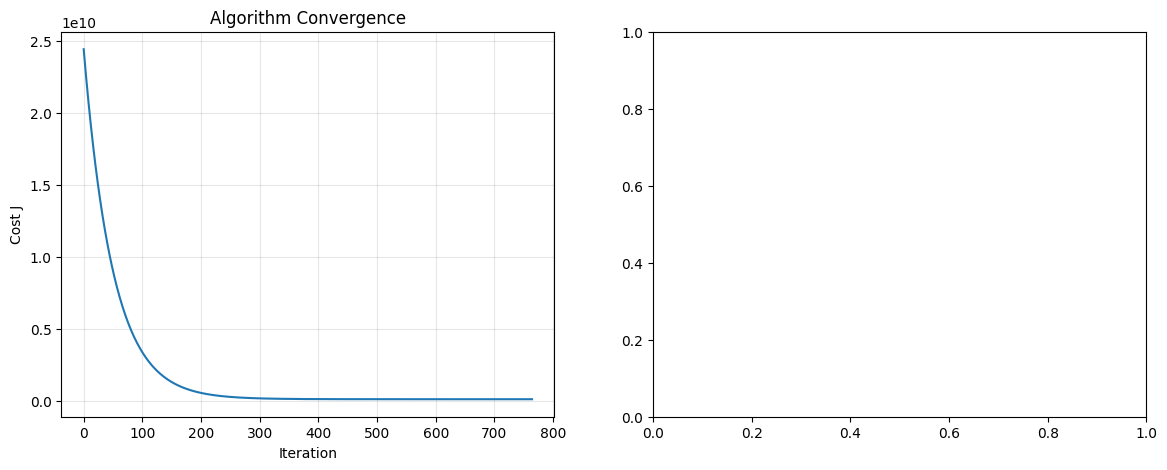

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost convergence
axes[0].plot(history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J')
axes[0].set_title('Algorithm Convergence')
axes[0].grid(alpha=0.3)

# Final model vs data
area_line = np.linspace(45, 105, 100)
price_line = w0_original + w1_original * area_line

axes[1].scatter(area, price/1000, s=80, color='steelblue', label='Actual data', alpha=0.8)
axes[1].plot(area_line, price_line/1000, 'r-', linewidth=2, label='GD Model')
axes[1].set_xlabel('Area (m²)')
axes[1].set_ylabel('Price (thousands of $)')
axes[1].set_title('Final Model Fit')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prediction example
new_area = 75
pred = w0_original + w1_original * new_area
print(f"\nPrediction: House of {new_area} m² → ${pred:,.0f}")

Done! You've implemented Gradient Descent from scratch and obtained a functional model. In Part 2, we'll explore hyperparameters, more advanced variants (Mini-Batch, SGD), and comparison with scikit-learn.